In [ ]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
customers = pd.read_csv('E:\PROJECT\olist_customers_dataset.csv')
orders = pd.read_csv('E:\PROJECT\olist_orders_dataset.csv')
reviews = pd.read_csv('E:\PROJECT\olist_order_reviews_dataset.csv')
items = pd.read_csv('E:\PROJECT\olist_order_items_dataset.csv')
products = pd.read_csv('E:\PROJECT\olist_products_dataset.csv')
translation = pd.read_csv('E:\PROJECT\product_category_name_translation.csv')
payments = pd.read_csv('E:\PROJECT\olist_order_payments_dataset.csv')

In [214]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [231]:
#DELIVERY DELAY
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

#(Actual - Estimated)
orders['delivery_delay'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days
orders['is_late'] = orders['delivery_delay'].apply(lambda x: 1 if x > 0 else 0)

In [185]:
#FILTER DATA FOR RECENCY ANALYSIS
active_status = ['delivered','shipped','invoiced','processing','approved','created']
orders_clean = orders[orders['order_status'].isin(active_status)].copy()
orders_clean['order_purchase_timestamp'] = pd.to_datetime(orders_clean['order_purchase_timestamp'])
order_cust = pd.merge(orders_clean, customers[['customer_id', 'customer_unique_id']], on='customer_id')

#R_ANALYSIS
latest_time = orders_clean['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

R_analysis_df = order_cust.groupby('customer_unique_id').agg({'order_purchase_timestamp': lambda x: (latest_time-x.max()).days}).reset_index()
R_analysis_df.rename(columns={'order_purchase_timestamp':'Recency'}, inplace=True)

R_analysis_df

,customer_unique_id,Recency
0,0000366f3b9a7992bf8c76cfdf3221e2,116
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119
2,0000f46a3911fa3c0805444483337064,542
3,0000f6ccb0745a6a4b88665a16c9f078,326
4,0004aac84e0df4da2b147fca70cf8255,293
...,...,...
94985,fffcf5a5ff07b0908bd4e2dbc735a684,452
94986,fffea47cd6d3cc0a88bd621562a9d061,267
94987,ffff371b4d645b6ecea244b27531430a,573
94988,ffff5962728ec6157033ef9805bacc48,124


In [205]:
#FILTER FOR FREQUENCY AND MONETARY ANALYSIS
active_status = ['delivered']
orders_clean = orders[orders['order_status'].isin(active_status)].copy()
order_cust = pd.merge(orders_clean, customers[['customer_id', 'customer_unique_id']], on='customer_id')

#Frequency Analysis 
F_analysis = order_cust.groupby('customer_unique_id').agg({'order_id':'nunique'}).reset_index()
F_analysis.rename(columns={'order_id':'Frequency'}, inplace=True)

#Monetary Analysis
order_payments = payments.groupby('order_id')['payment_value'].sum().reset_index()
monetary = pd.merge(order_cust[['order_id', 'customer_unique_id']], order_payments, on='order_id')
monetary = monetary.groupby('customer_unique_id')['payment_value'].sum().reset_index()
monetary.columns = ['customer_unique_id', 'Monetary']

rfm = R_analysis_df.merge(F_analysis, on='customer_unique_id').merge(monetary, on='customer_unique_id')
rfm

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19
2,0000f46a3911fa3c0805444483337064,542,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,293,1,196.89
...,...,...,...,...
93352,fffcf5a5ff07b0908bd4e2dbc735a684,452,1,2067.42
93353,fffea47cd6d3cc0a88bd621562a9d061,267,1,84.58
93354,ffff371b4d645b6ecea244b27531430a,573,1,112.46
93355,ffff5962728ec6157033ef9805bacc48,124,1,133.69


In [210]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

def segment_me(df):
    score = int(df['R_score']) + int(df['F_score'])
    if score >= 9: return 'Champions'
    elif score >= 7: return 'Loyal Customers'
    elif score >= 5: return 'Potential Loyalists'
    elif score >= 3: return 'At Risk'
    else: return 'Lost'

rfm['Segment'] = rfm.apply(segment_me, axis=1)

In [212]:
summary = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'customer_unique_id': 'count'
}).rename(columns={'customer_unique_id': 'Total_Customers'}).sort_values('Monetary', ascending=False).reset_index()

print(summary)

               Segment     Recency  Frequency    Monetary  Total_Customers
0            Champions   80.669564   1.122992  180.967186            11391
1      Loyal Customers  164.560414   1.047948  166.661099            26070
2  Potential Loyalists  263.869902   1.013972  161.903682            33567
3                 Lost  478.873070   1.000000  160.798163             3821
4              At Risk  364.605738   1.000000  160.318729            18508


In [215]:
rfm['is_churn'] = (rfm['Recency'] > 180).astype(int)

In [237]:
master_df = rfm.merge(order_cust[['customer_unique_id', 'order_id']], on='customer_unique_id', how='left'
                  ).merge(items[['order_id', 'product_id', 'price', 'freight_value']], on='order_id', how='left'
                  ).merge(customers[['customer_unique_id', 'customer_state']], on='customer_unique_id', how='left'
                  ).merge(products[['product_id', 'product_category_name']], on='product_id', how='left'
                  ).merge(translation, on='product_category_name', how='left'
                  ).merge(orders[['order_id', 'delivery_delay', 'is_late']], on='order_id', how='left'
                  )

master_df.drop(columns=['product_category_name'], inplace=True)

master_df

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment,is_churn,order_id,product_id,price,freight_value,customer_state,product_category_name_english,delivery_delay,is_late
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90,4,1,4,Potential Loyalists,0,e22acc9c116caa3f2b7121bbb380d08e,372645c7439f9661fbbacfd129aa92ec,129.90,12.00,SP,bed_bath_table,-5.0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19,4,1,1,Potential Loyalists,0,3594e05a005ac4d06a72673270ef9ec9,5099f7000472b634fea8304448d20825,18.90,8.29,SP,health_beauty,-5.0,0
2,0000f46a3911fa3c0805444483337064,542,1,86.22,1,1,2,Lost,1,b33ec3b699337181488304f362a6b734,64b488de448a5324c4134ea39c28a34b,69.00,17.22,SC,stationery,-2.0,0
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62,2,1,1,At Risk,1,41272756ecddd9a9ed0180413cc22fb6,2345a354a6f2033609bbf62bf5be9ef6,25.99,17.63,PA,telephony,-12.0,0
4,0004aac84e0df4da2b147fca70cf8255,293,1,196.89,2,1,4,At Risk,1,d957021f1127559cd947b62533f484f7,c72e18b3fe2739b8d24ebf3102450f37,180.00,16.89,SP,telephony,-8.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119461,fffcf5a5ff07b0908bd4e2dbc735a684,452,1,2067.42,1,5,5,Potential Loyalists,1,725cf8e9c24e679a8a5a32cb92c9ce1e,bbc5419bc92d76e27795c9ec2c233c64,680.00,239.14,PE,health_beauty,-27.0,0
119462,fffea47cd6d3cc0a88bd621562a9d061,267,1,84.58,3,5,2,Loyal Customers,1,c71b9252fd7b3b263aaa4cb09319a323,251876e7ba013b87b7262fb2524e2d60,64.89,19.69,BA,baby,-3.0,0
119463,ffff371b4d645b6ecea244b27531430a,573,1,112.46,1,5,3,Potential Loyalists,1,fdc45e6c7555e6cb3cc0daca2557dbe1,13ad6994bda56edfa0a269e3d9a9acb3,89.90,22.56,MT,auto,-30.0,0
119464,ffff5962728ec6157033ef9805bacc48,124,1,133.69,4,5,4,Champions,0,94d3ee0bc2a0af9d4fa47a4d63616e8d,461f43be3bdf8844e65b62d9ac2c7a5a,115.00,18.69,ES,watches_gifts,-14.0,0


In [238]:
print(rfm['customer_unique_id'].nunique())
print(master_df['customer_unique_id'].nunique())

93357
93357


In [239]:
master_df.to_csv('DATA.csv',index=False)

In [ ]:
df = pd.read_csv('DATA.csv')
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Target Variable Distribution ---")
print(df['is_churn'].value_counts(normalize=True))
print("\n--- First few rows ---")
print(df.head())

In [259]:
#Add "PRODUCT/ORDER" Variable
order_counts = df.groupby('order_id').size().reset_index(name='quantity')
df = df.merge(order_counts, on='order_id', how='left')

In [ ]:
%pip install scikit-learn

Accuracy: 0.8941

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.84      0.87      9695
           1       0.89      0.93      0.91     14199

    accuracy                           0.89     23894
   macro avg       0.89      0.89      0.89     23894
weighted avg       0.89      0.89      0.89     23894



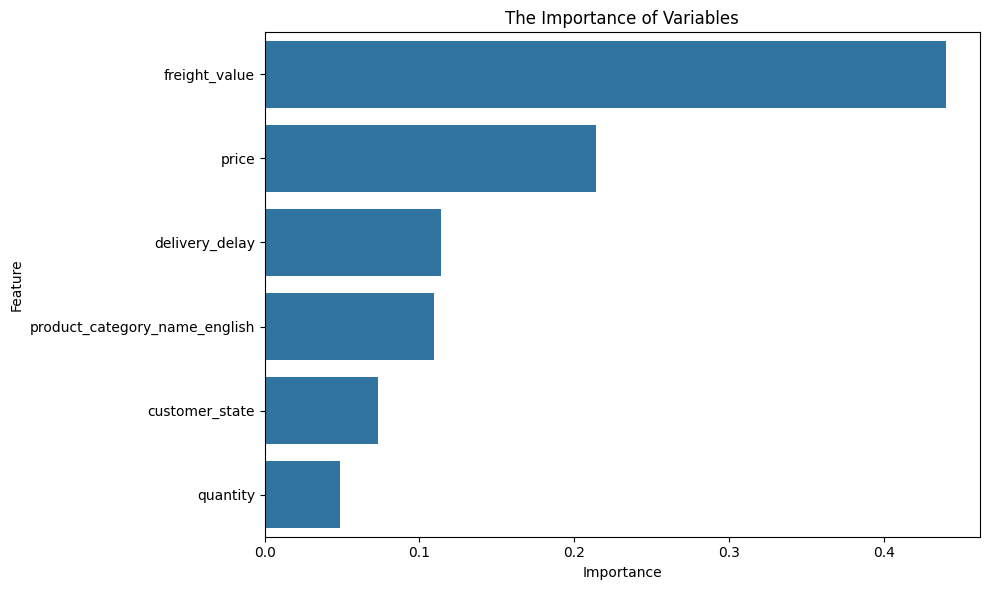

In [261]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

#Remove RFM since is_churn was bulit by RFM
columns_to_drop = [
    'customer_unique_id', 'order_id', 'product_id', 'is_late', # ID
    'Recency', 'Frequency', 'Monetary',                       # original RFM
    'R_score', 'F_score', 'M_score', 'Segment'                # calculated RFM
]
df = df.drop(columns=columns_to_drop)

#Adjust Missing Values
df['product_category_name_english'] = df['product_category_name_english'].fillna('Unknown')
df['delivery_delay'] = df['delivery_delay'].fillna(df['delivery_delay'].median())

#Categorical Variables
label_encoders = {}
for col in ['customer_state', 'product_category_name_english']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le


X = df.drop(columns=['is_churn'])
y = df['is_churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


rf_model_v2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf_model_v2.fit(X_train, y_train)

#PREDICTION 
y_pred = rf_model_v2.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

#FEATURE IMPORTANCE
feature_importances = pd.Series(rf_model_v2.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title('The Importance of Variables')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [263]:
def predict_new_customer(price, freight_value, delivery_delay, product_category, customer_state, quantity):
    try:
        category_encoded = label_encoders['product_category_name_english'].transform([product_category])[0]
        state_encoded = label_encoders['customer_state'].transform([customer_state])[0]
    except:
        category_encoded = 0 
        state_encoded = 0


    new_data = pd.DataFrame([{
        'price': price,
        'freight_value': freight_value,
        'customer_state': state_encoded,
        'product_category_name_english': category_encoded,
        'delivery_delay': delivery_delay,
        'quantity': quantity
    }])


    prediction = rf_model_v2.predict(new_data)[0]
    probability = rf_model_v2.predict_proba(new_data)[0]

    
    result = "CHURN" if prediction == 1 else "STAY"
    print(f"--- THE RESULT ---")
    print(f"STATUS {result}")
    print(f"The Probability of Churn: {probability[1]*100:.2f}%")
    print(f"The Probability of Stay {probability[0]*100:.2f}%")


predict_new_customer(
    price=500.0, 
    freight_value=50.0, 
    delivery_delay=2.0, 
    product_category='health_beauty',
    customer_state='SP', 
    quantity=5
)

--- THE RESULT ---
STATUS STAY
The Probability of Churn: 44.00%
The Probability of Stay 56.00%
